In [1]:
import os
import warnings
import sys
warnings.filterwarnings('ignore')

# Print current working directory
print(f"Current working directory: {os.getcwd()}")

# Install required packages
print("\nInstalling required packages...")
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'imbalanced-learn', 'scikit-optimize', '-q'])

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import time

print("✓ All imports successful")

Current working directory: /home/xeeshan/5) Top 10 Data Sciecne & Generative AI Projects /churn_prediction

Installing required packages...
✓ All imports successful


In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn 
import os
import pickle
import joblib
import datetime

In [3]:
df  = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df.drop(columns=['customerID', 'gender', 'PhoneService'], inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   MultipleLines     7043 non-null   object 
 5   InternetService   7043 non-null   object 
 6   OnlineSecurity    7043 non-null   object 
 7   OnlineBackup      7043 non-null   object 
 8   DeviceProtection  7043 non-null   object 
 9   TechSupport       7043 non-null   object 
 10  StreamingTV       7043 non-null   object 
 11  StreamingMovies   7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   object 


In [11]:
 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, drop_first=True)

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   MultipleLines_No phone service         7043 non-null   bool   
 8   MultipleLines_Yes                      7043 non-null   bool   
 9   InternetService_Fiber optic            7043 non-null   bool   
 10  InternetService_No                     7043 non-null   bool   
 11  Onli

In [13]:
# Find all boolean columns
bool_cols = df.select_dtypes(include=["bool"]).columns

# Convert True/False to 1/0
df[bool_cols] = df[bool_cols].astype(int)

# Check result
print(df[bool_cols].dtypes.head())
df.head()

Partner_Yes                       int64
Dependents_Yes                    int64
MultipleLines_No phone service    int64
MultipleLines_Yes                 int64
InternetService_Fiber optic       int64
dtype: object


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0


In [14]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
binary_cols =  [c for c in df.columns if df[c].dtype == "bool"] + ["SeniorCitizen", "Churn"]

Numeric summary
                 count         mean          std    min     25%      50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  


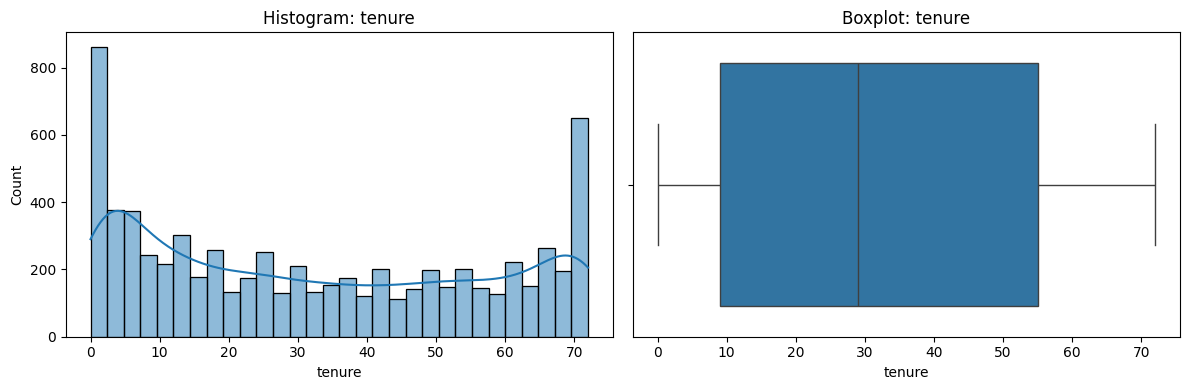

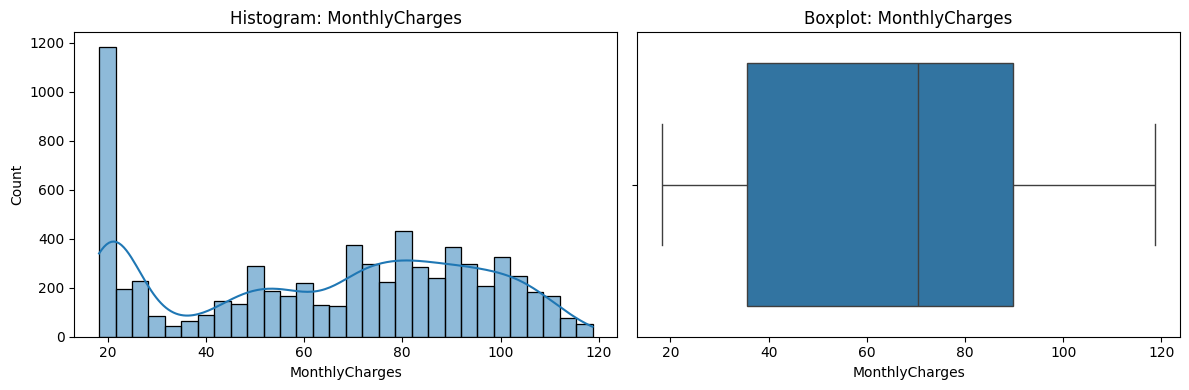

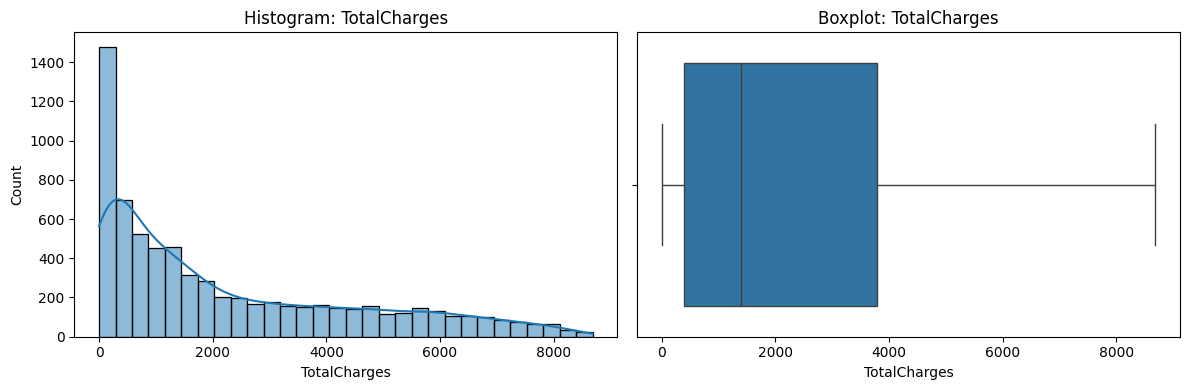

In [15]:
import seaborn as sns
print("Numeric summary")
print(df[num_cols].describe().T)

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=ax[0], bins=30)
    ax[0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

OUTLIER DETECTION (IQR Method)

            Column      Q1       Q3      IQR  Lower_Bound  Upper_Bound  Outlier_Count  Outlier_%
0          tenure    9.00    55.00    46.00      -60.000      124.000              0        0.0
1  MonthlyCharges   35.50    89.85    54.35      -46.025      171.375              0        0.0
2    TotalCharges  398.55  3786.60  3388.05    -4683.525     8868.675              0        0.0


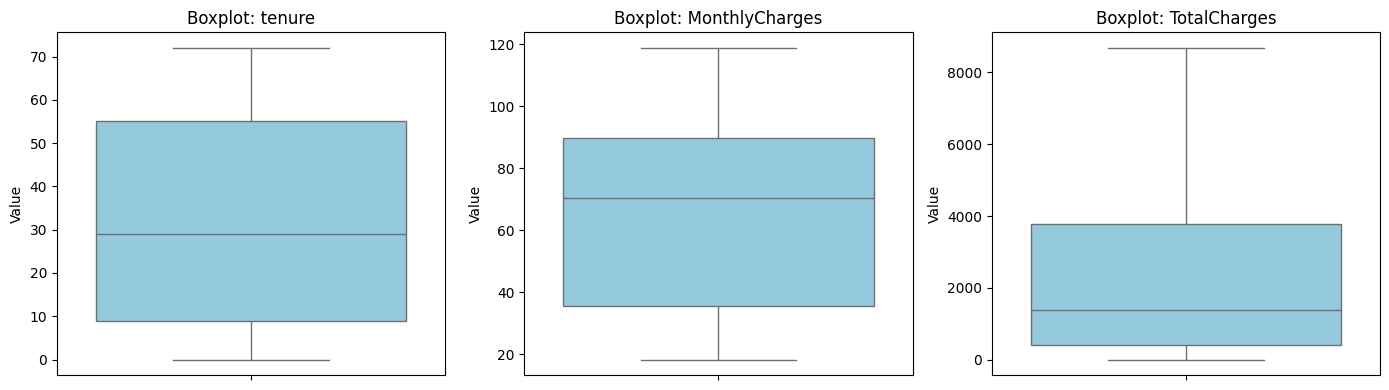


Outlier Summary:            Column      Q1       Q3      IQR  Lower_Bound  Upper_Bound  \
0          tenure    9.00    55.00    46.00      -60.000      124.000   
1  MonthlyCharges   35.50    89.85    54.35      -46.025      171.375   
2    TotalCharges  398.55  3786.60  3388.05    -4683.525     8868.675   

   Outlier_Count  Outlier_%  
0              0        0.0  
1              0        0.0  
2              0        0.0  


In [16]:
# ===== 1. OUTLIER DETECTION (IQR Method) =====
print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)

outlier_summary = []
for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((s < lower_bound) | (s > upper_bound)).sum()
    outlier_pct = (outliers / len(s)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outliers,
        'Outlier_%': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n", outlier_df.to_string())

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for idx, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel('Value')
plt.tight_layout()
plt.show()

print("\nOutlier Summary:", outlier_df)


SKEWNESS & KURTOSIS ANALYSIS

         Column  Skewness  Kurtosis                    Type
        tenure     0.240    -1.387        Fairly Symmetric
MonthlyCharges    -0.221    -1.257        Fairly Symmetric
  TotalCharges     0.963    -0.229 Right-Skewed (Positive)


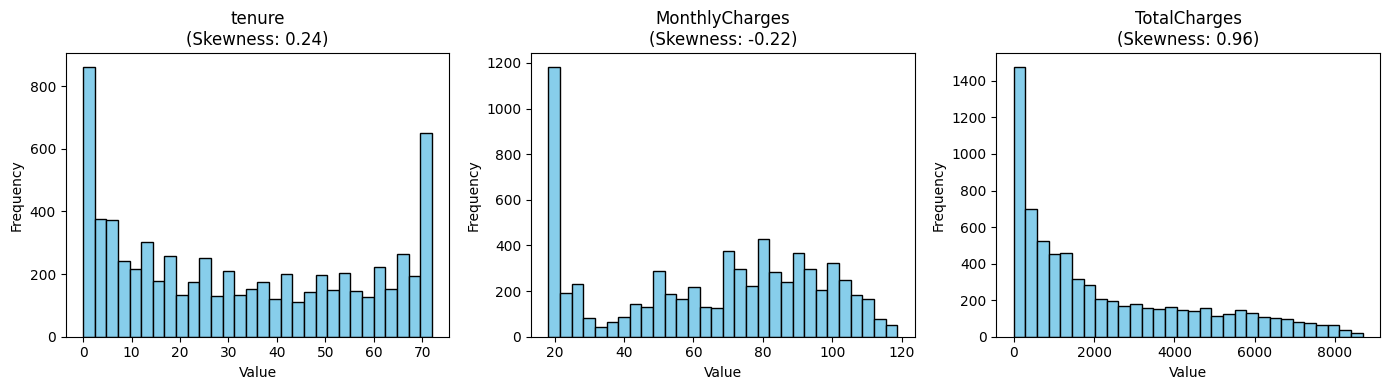

In [17]:
# ===== 2. SKEWNESS & KURTOSIS ANALYSIS =====
print("\n" + "="*60)
print("SKEWNESS & KURTOSIS ANALYSIS")
print("="*60)

skewness_summary = []
for col in num_cols:
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    
    # Interpretation
    if abs(skew_val) < 0.5:
        skew_type = "Fairly Symmetric"
    elif skew_val > 0.5:
        skew_type = "Right-Skewed (Positive)"
    else:
        skew_type = "Left-Skewed (Negative)"
    
    skewness_summary.append({
        'Column': col,
        'Skewness': round(skew_val, 3),
        'Kurtosis': round(kurt_val, 3),
        'Type': skew_type
    })

skew_df = pd.DataFrame(skewness_summary)
print("\n", skew_df.to_string(index=False))

# Visualize skewness with histograms
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', color='skyblue')
    axes[idx].set_title(f'{col}\n(Skewness: {df[col].skew():.2f})')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


NORMALIZATION & DISTRIBUTION TRANSFORMATION

✓ StandardScaler applied
✓ MinMaxScaler (0-1) applied
✓ RobustScaler applied
✓ Yeo-Johnson PowerTransformer applied


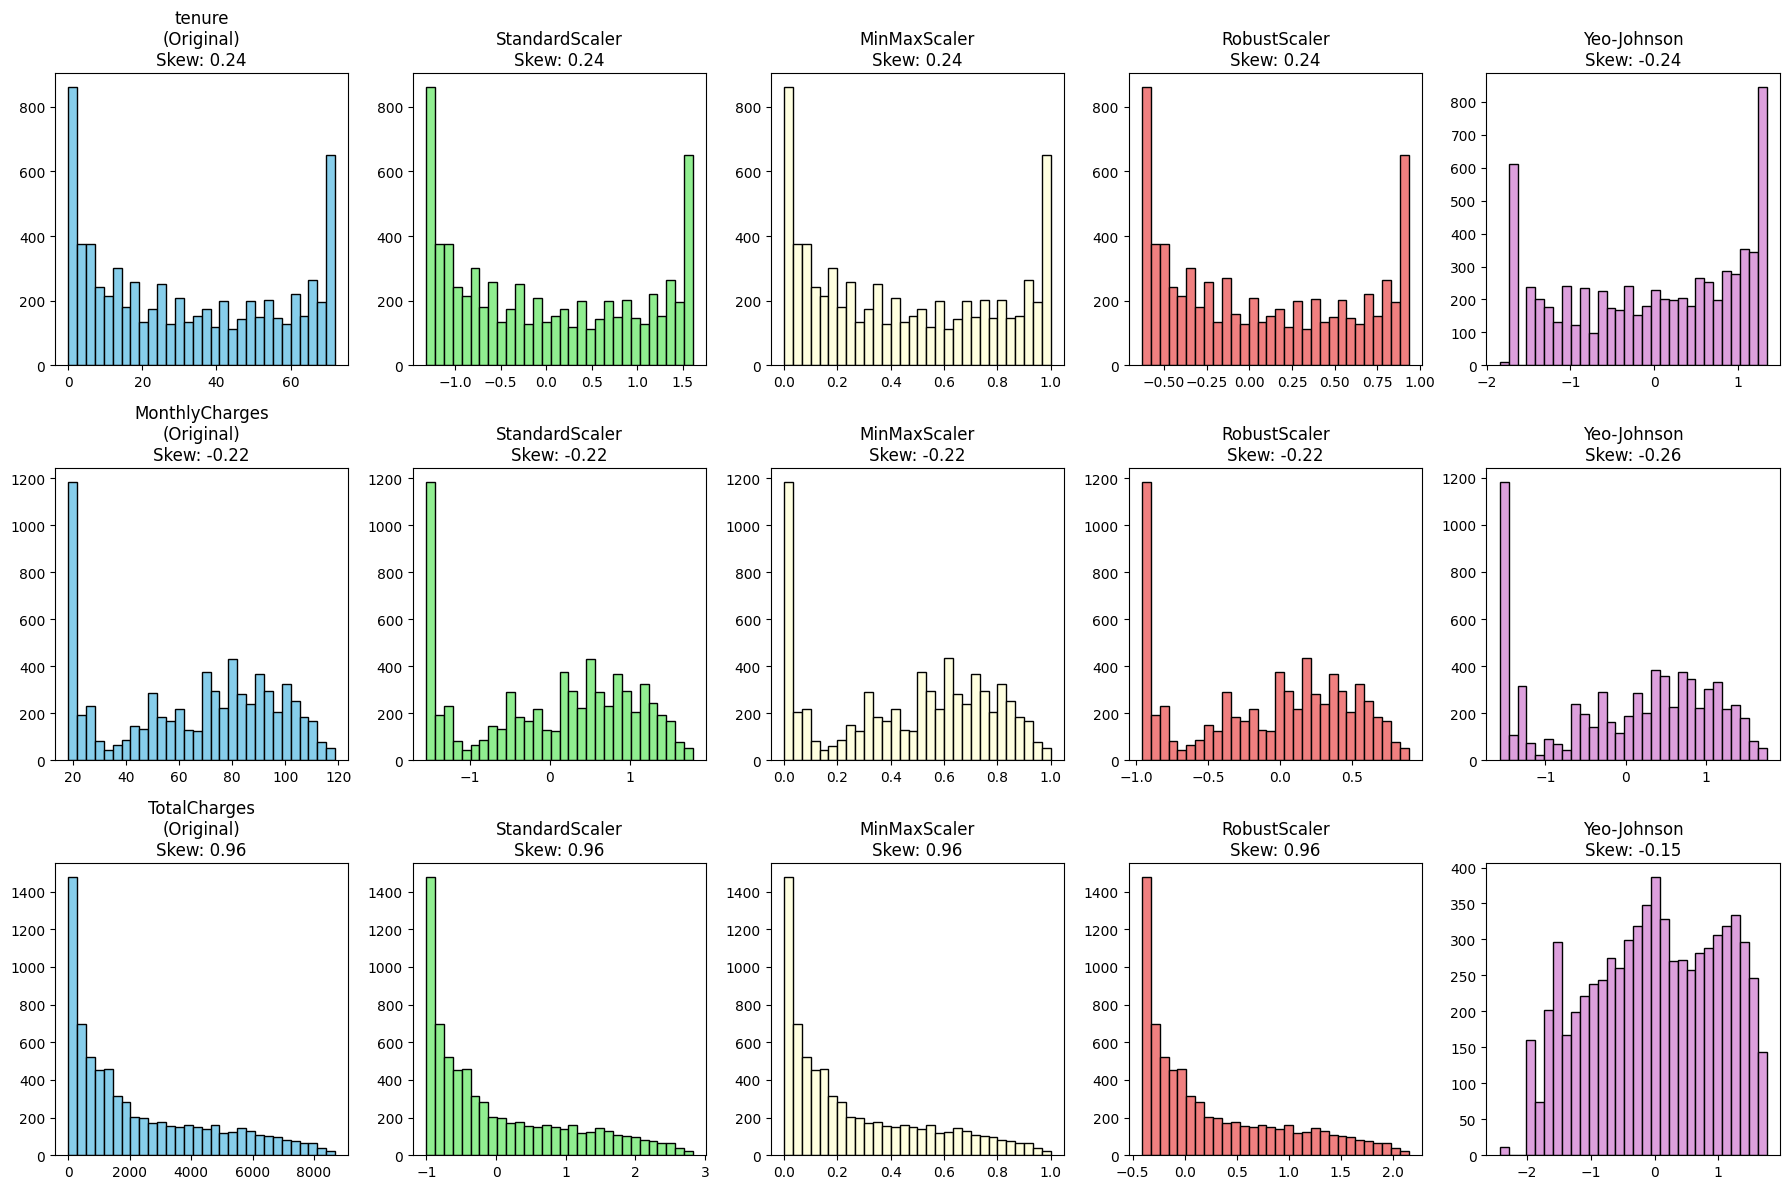


✓ Use df_standard for StandardScaler (most common)
✓ Use df_minmax for MinMaxScaler (0-1 range)
✓ Use df_robust for RobustScaler (robust to outliers)
✓ Use df_yeo_johnson for PowerTransformer (approximate normality)


In [18]:
# ===== 3. NORMALIZATION & DISTRIBUTION TRANSFORMATION =====
print("\n" + "="*60)
print("NORMALIZATION & DISTRIBUTION TRANSFORMATION")
print("="*60)

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from scipy import stats

# Create copies for different scaling methods
df_standard = df.copy()
df_minmax = df.copy()
df_robust = df.copy()
df_yeo_johnson = df.copy()

# 1. StandardScaler (Z-score normalization)
scaler_standard = StandardScaler()
df_standard[num_cols] = scaler_standard.fit_transform(df[num_cols])

# 2. MinMaxScaler (0-1 scaling)
scaler_minmax = MinMaxScaler()
df_minmax[num_cols] = scaler_minmax.fit_transform(df[num_cols])

# 3. RobustScaler (robust to outliers)
scaler_robust = RobustScaler()
df_robust[num_cols] = scaler_robust.fit_transform(df[num_cols])

# 4. Yeo-Johnson PowerTransformer (normalize distribution)
pt = PowerTransformer(method='yeo-johnson')
df_yeo_johnson[num_cols] = pt.fit_transform(df[num_cols])

print("\n✓ StandardScaler applied")
print("✓ MinMaxScaler (0-1) applied")
print("✓ RobustScaler applied")
print("✓ Yeo-Johnson PowerTransformer applied")

# Compare distributions before and after
fig, axes = plt.subplots(len(num_cols), 5, figsize=(18, 12))
for idx, col in enumerate(num_cols):
    # Original
    axes[idx, 0].hist(df[col], bins=30, edgecolor='black', color='skyblue')
    axes[idx, 0].set_title(f'{col}\n(Original)\nSkew: {df[col].skew():.2f}')
    
    # StandardScaler
    axes[idx, 1].hist(df_standard[col], bins=30, edgecolor='black', color='lightgreen')
    axes[idx, 1].set_title(f'StandardScaler\nSkew: {df_standard[col].skew():.2f}')
    
    # MinMaxScaler
    axes[idx, 2].hist(df_minmax[col], bins=30, edgecolor='black', color='lightyellow')
    axes[idx, 2].set_title(f'MinMaxScaler\nSkew: {df_minmax[col].skew():.2f}')
    
    # RobustScaler
    axes[idx, 3].hist(df_robust[col], bins=30, edgecolor='black', color='lightcoral')
    axes[idx, 3].set_title(f'RobustScaler\nSkew: {df_robust[col].skew():.2f}')
    
    # Yeo-Johnson
    axes[idx, 4].hist(df_yeo_johnson[col], bins=30, edgecolor='black', color='plum')
    axes[idx, 4].set_title(f'Yeo-Johnson\nSkew: {df_yeo_johnson[col].skew():.2f}')

plt.tight_layout()
plt.show()

print("\n✓ Use df_standard for StandardScaler (most common)")
print("✓ Use df_minmax for MinMaxScaler (0-1 range)")
print("✓ Use df_robust for RobustScaler (robust to outliers)")
print("✓ Use df_yeo_johnson for PowerTransformer (approximate normality)")


SPARSITY CHECK (Zero & Null Values)

                                    Column  Total  Zeros  Nulls  Sparsity_%  Non-Zero_%
7          MultipleLines_No phone service   7043   6361      0       90.32        9.68
0                           SeniorCitizen   7043   5901      0       83.79       16.21
23                      Contract_One year   7043   5570      0       79.09       20.91
26  PaymentMethod_Credit card (automatic)   7043   5521      0       78.39       21.61
11     OnlineSecurity_No internet service   7043   5517      0       78.33       21.67
21    StreamingMovies_No internet service   7043   5517      0       78.33       21.67
19        StreamingTV_No internet service   7043   5517      0       78.33       21.67
17        TechSupport_No internet service   7043   5517      0       78.33       21.67
15   DeviceProtection_No internet service   7043   5517      0       78.33       21.67
13       OnlineBackup_No internet service   7043   5517      0       78.33       21.67
10  

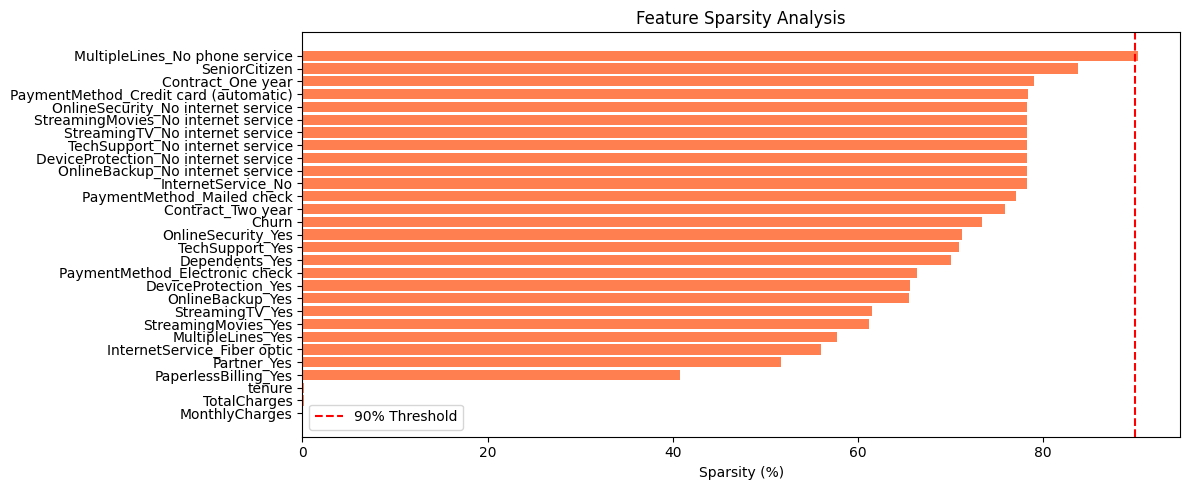

In [19]:
# ===== 4. SPARSITY CHECK =====
print("\n" + "="*60)
print("SPARSITY CHECK (Zero & Null Values)")
print("="*60)

sparsity_data = []
for col in df.columns:
    zero_count = (df[col] == 0).sum()
    null_count = df[col].isnull().sum()
    total = len(df)
    sparsity_pct = ((zero_count + null_count) / total) * 100
    
    sparsity_data.append({
        'Column': col,
        'Total': total,
        'Zeros': zero_count,
        'Nulls': null_count,
        'Sparsity_%': round(sparsity_pct, 2),
        'Non-Zero_%': round(100 - sparsity_pct, 2)
    })

sparsity_df = pd.DataFrame(sparsity_data).sort_values('Sparsity_%', ascending=False)
print("\n", sparsity_df.to_string())

# Identify highly sparse columns (>90% sparse)
highly_sparse = sparsity_df[sparsity_df['Sparsity_%'] > 90]
if len(highly_sparse) > 0:
    print("\n⚠️  HIGHLY SPARSE COLUMNS (>90% sparse):")
    print(highly_sparse[['Column', 'Sparsity_%']].to_string(index=False))
else:
    print("\n✓ No highly sparse columns detected")

# Visualize sparsity
fig, ax = plt.subplots(figsize=(12, 5))
sparsity_sorted = sparsity_df.sort_values('Sparsity_%', ascending=True)
ax.barh(sparsity_sorted['Column'], sparsity_sorted['Sparsity_%'], color='coral')
ax.set_xlabel('Sparsity (%)')
ax.set_title('Feature Sparsity Analysis')
ax.axvline(x=90, color='red', linestyle='--', label='90% Threshold')
ax.legend()
plt.tight_layout()
plt.show()


CLASS IMBALANCE ANALYSIS (Target Variable)

        Class  Count  Percentage
No Churn (0)   5174       73.46
   Churn (1)   1869       26.54

Imbalance Ratio: 2.77:1
⚠️  MODERATELY IMBALANCED - Monitor model performance closely


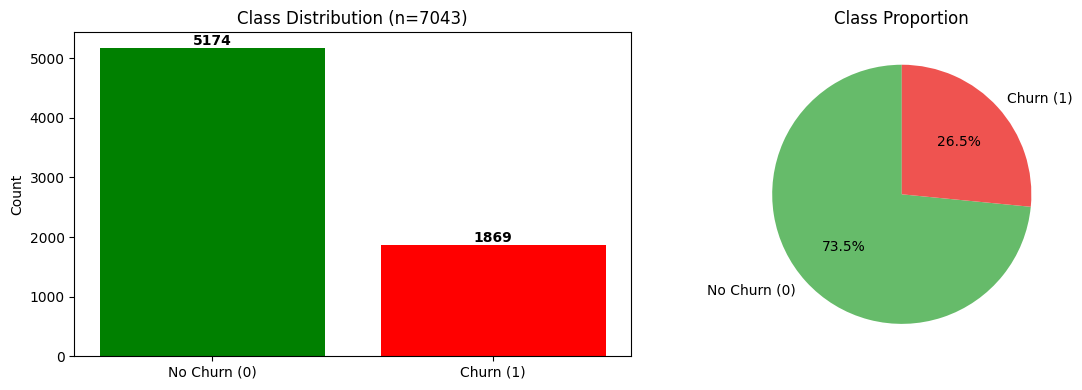


DATA QUALITY SUMMARY
Total Records: 7043
Total Features: 29
Numeric Features: 3
Binary Features: 27
Missing Values: 0
Duplicates: 41


In [20]:
# ===== 5. CLASS IMBALANCE ANALYSIS =====
print("\n" + "="*60)
print("CLASS IMBALANCE ANALYSIS (Target Variable)")
print("="*60)

target_col = 'Churn'
class_counts = df[target_col].value_counts().sort_index()
class_pct = (df[target_col].value_counts(normalize=True) * 100).sort_index()

imbalance_data = []
for cls in class_counts.index:
    count = class_counts[cls]
    pct = class_pct[cls]
    label = "No Churn" if cls == 0 else "Churn"
    imbalance_data.append({
        'Class': f'{label} ({cls})',
        'Count': count,
        'Percentage': round(pct, 2)
    })

imbalance_df = pd.DataFrame(imbalance_data)
print("\n", imbalance_df.to_string(index=False))

# Calculate imbalance ratio
class_0_count = class_counts[0]
class_1_count = class_counts[1]
imbalance_ratio = max(class_0_count, class_1_count) / min(class_0_count, class_1_count)
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("⚠️  HIGHLY IMBALANCED DATA - Consider resampling techniques:")
    print("   • SMOTE (Synthetic Minority Over-sampling Technique)")
    print("   • Random Over-sampling / Under-sampling")
    print("   • Class Weights in model")
elif imbalance_ratio > 1.5:
    print("⚠️  MODERATELY IMBALANCED - Monitor model performance closely")
else:
    print("✓ DATA IS RELATIVELY BALANCED")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(imbalance_df['Class'], imbalance_df['Count'], color=['green', 'red'])
axes[0].set_title(f'Class Distribution (n={len(df)})')
axes[0].set_ylabel('Count')
for i, v in enumerate(imbalance_df['Count']):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
colors_pie = ['#66bb6a', '#ef5350']
axes[1].pie(imbalance_df['Count'], labels=imbalance_df['Class'], autopct='%1.1f%%', 
            colors=colors_pie, startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DATA QUALITY SUMMARY")
print("="*60)
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"Numeric Features: {len(num_cols)}")
print(f"Binary Features: {len([c for c in df.columns if df[c].dtype in ['int64', 'bool']])}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

In [21]:
# ===== 6. REMOVE OUTLIERS (IQR Method) =====
print("\n" + "="*60)
print("REMOVING OUTLIERS (IQR Method)")
print("="*60)

# Store original shape
original_shape = df.shape
print(f"Original dataset shape: {original_shape}")

# Remove outliers for numeric columns
df_no_outliers = df.copy()

outliers_removed_count = 0
for col in num_cols:
    s = df_no_outliers[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Count outliers before removal
    outlier_mask = (s < lower_bound) | (s > upper_bound)
    removed = outlier_mask.sum()
    outliers_removed_count += removed
    
    # Remove rows with outliers
    df_no_outliers = df_no_outliers[~outlier_mask]
    
    print(f"\n{col}:")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers removed: {removed}")

print(f"\nTotal rows removed: {outliers_removed_count}")
print(f"Remaining rows: {df_no_outliers.shape[0]}")
print(f"Rows removed: {original_shape[0] - df_no_outliers.shape[0]}")
print(f"Percentage removed: {((original_shape[0] - df_no_outliers.shape[0]) / original_shape[0] * 100):.2f}%")

# Verify no outliers remain
print("\n✓ Outliers removed successfully")
print(f"New dataset shape: {df_no_outliers.shape}")

# Summary statistics comparison
print("\n" + "-"*60)
print("STATISTICS COMPARISON (Before vs After Outlier Removal)")
print("-"*60)
comparison_stats = pd.DataFrame({
    'Before (Mean)': df[num_cols].mean(),
    'After (Mean)': df_no_outliers[num_cols].mean(),
    'Before (Std)': df[num_cols].std(),
    'After (Std)': df_no_outliers[num_cols].std()
})
print(comparison_stats)


REMOVING OUTLIERS (IQR Method)
Original dataset shape: (7043, 29)

tenure:
  Bounds: [-60.00, 124.00]
  Outliers removed: 0

MonthlyCharges:
  Bounds: [-46.02, 171.38]
  Outliers removed: 0

TotalCharges:
  Bounds: [-4683.52, 8868.67]
  Outliers removed: 0

Total rows removed: 0
Remaining rows: 7043
Rows removed: 0
Percentage removed: 0.00%

✓ Outliers removed successfully
New dataset shape: (7043, 29)

------------------------------------------------------------
STATISTICS COMPARISON (Before vs After Outlier Removal)
------------------------------------------------------------
                Before (Mean)  After (Mean)  Before (Std)  After (Std)
tenure              32.371149     32.371149     24.559481    24.559481
MonthlyCharges      64.761692     64.761692     30.090047    30.090047
TotalCharges      2279.734304   2279.734304   2266.794470  2266.794470



FIXING CLASS IMBALANCE USING SMOTE

Before SMOTE:
Total records: 7043
No Churn (0): 5174
Churn (1): 1869
Imbalance Ratio: 2.77:1

Applying SMOTE...

After SMOTE:
Total records: 10348
No Churn (0): 5174
Churn (1): 5174
Imbalance Ratio: 1.00:1
✓ Data is now BALANCED!

------------------------------------------------------------
VERIFICATION
------------------------------------------------------------
Total Records: 10348
Total Features: 29
Missing Values: 0
Duplicates: 65


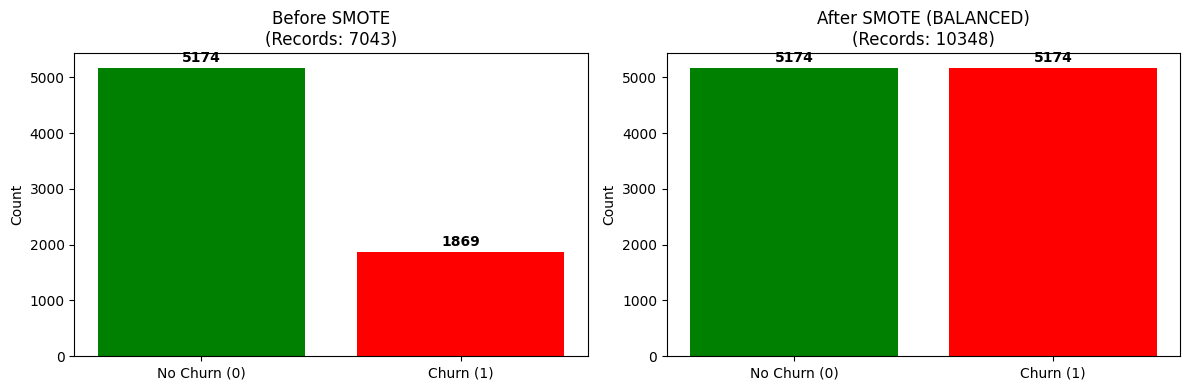


SUMMARY: DATA PREPROCESSING COMPLETE
✓ Outliers removed using IQR method
✓ Class imbalance fixed using SMOTE
✓ Final dataset ready for modeling

Final Dataset:
  Shape: (10348, 29)
  Class Distribution: {0: 5174, 1: 5174}

Use 'df_balanced' for model training


In [22]:
# ===== 7. FIX CLASS IMBALANCE USING SMOTE =====
!pip install imbalanced-learn
print("\n" + "="*60)
print("FIXING CLASS IMBALANCE USING SMOTE")
print("="*60)

from imblearn.over_sampling import SMOTE

# Prepare data for SMOTE
X_before = df_no_outliers.drop(columns=['Churn'])
y_before = df_no_outliers['Churn']

print(f"\nBefore SMOTE:")
print(f"Total records: {len(X_before)}")
print(f"No Churn (0): {(y_before == 0).sum()}")
print(f"Churn (1): {(y_before == 1).sum()}")
print(f"Imbalance Ratio: {(y_before == 0).sum() / (y_before == 1).sum():.2f}:1")

# Apply SMOTE
print("\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_before, y_before)

print(f"\nAfter SMOTE:")
print(f"Total records: {len(X_smote)}")
print(f"No Churn (0): {(y_smote == 0).sum()}")
print(f"Churn (1): {(y_smote == 1).sum()}")
print(f"Imbalance Ratio: {(y_smote == 0).sum() / (y_smote == 1).sum():.2f}:1")
print(f"✓ Data is now BALANCED!")

# Recreate balanced dataframe
df_balanced = X_smote.copy()
df_balanced['Churn'] = y_smote

# Verification
print("\n" + "-"*60)
print("VERIFICATION")
print("-"*60)
print(f"Total Records: {len(df_balanced)}")
print(f"Total Features: {len(df_balanced.columns)}")
print(f"Missing Values: {df_balanced.isnull().sum().sum()}")
print(f"Duplicates: {df_balanced.duplicated().sum()}")

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
churn_before = y_before.value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], [churn_before[0], churn_before[1]], color=['green', 'red'])
axes[0].set_title(f'Before SMOTE\n(Records: {len(y_before)})')
axes[0].set_ylabel('Count')
for i, v in enumerate([churn_before[0], churn_before[1]]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# After SMOTE
churn_after = y_smote.value_counts()
axes[1].bar(['No Churn (0)', 'Churn (1)'], [churn_after[0], churn_after[1]], color=['green', 'red'])
axes[1].set_title(f'After SMOTE (BALANCED)\n(Records: {len(y_smote)})')
axes[1].set_ylabel('Count')
for i, v in enumerate([churn_after[0], churn_after[1]]):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY: DATA PREPROCESSING COMPLETE")
print("="*60)
print(f"✓ Outliers removed using IQR method")
print(f"✓ Class imbalance fixed using SMOTE")
print(f"✓ Final dataset ready for modeling")
print(f"\nFinal Dataset:")
print(f"  Shape: {df_balanced.shape}")
print(f"  Class Distribution: {dict(y_smote.value_counts())}")
print(f"\nUse 'df_balanced' for model training")

In [23]:
# Option 1: Drop highly sparse columns (>90% sparse)
sparse_threshold = 0.90
sparse_cols = sparsity_df[sparsity_df['Sparsity_%'] > sparse_threshold]['Column'].tolist()
df_cleaned = df.drop(columns=sparse_cols)

# Option 2: Feature engineering - combine sparse columns
# Combine multiple sparse binary columns into one feature

# Option 3: Use sparse-aware algorithms (XGBoost, LightGBM handle sparsity well)

# # Option 4: Dimensionality reduction (PCA, feature selection)
# from sklearn.feature_selection import SelectKBest, f_classif
# selector = SelectKBest(f_classif, k=15)  # Select top 15 features
# X_selected = selector.fit_transform(X, y)


In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370,0.483033,0.299588,0.096834,0.421837,0.439585,...,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.592219,0.216101,0.335794,0.228880
std,0.368612,24.559481,30.090047,2266.794470,0.441561,0.499748,0.458110,0.295752,0.493888,0.496372,...,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.491457,0.411613,0.472301,0.420141
min,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [25]:
# ===== 8. TRAIN/TEST SPLIT & DATA STANDARDIZATION =====
print("="*60)
print("TRAIN/TEST SPLIT & PREPROCESSING")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df_balanced.drop(columns=['Churn'])
y = df_balanced['Churn']

print(f"\nDataset shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"\nClass distribution in train set:")
print(f"  No Churn (0): {(y_train == 0).sum()}")
print(f"  Churn (1): {(y_train == 1).sum()}")
print(f"\nClass distribution in test set:")
print(f"  No Churn (0): {(y_test == 0).sum()}")
print(f"  Churn (1): {(y_test == 1).sum()}")

print("\n✓ Data preprocessed and ready for model training")

TRAIN/TEST SPLIT & PREPROCESSING

Dataset shape: (10348, 28)
Features: 28
Samples: 10348

Train set: 8278 samples
Test set: 2070 samples

Class distribution in train set:
  No Churn (0): 4139
  Churn (1): 4139

Class distribution in test set:
  No Churn (0): 1035
  Churn (1): 1035

✓ Data preprocessed and ready for model training


In [26]:
# ===== 9. TRAIN MULTIPLE CLASSIFICATION MODELS =====
print("\n" + "="*60)
print("TRAINING MULTIPLE CLASSIFICATION MODELS")
print("="*60)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    # 'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# Store results
results = []
model_objects = {}

print("\nTraining models...")
for model_name, model in models.items():
    print(f"  ► {model_name}...", end=" ")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    model_objects[model_name] = model
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    })
    
    print(f"✓ (Accuracy: {accuracy:.4f})")

# Convert to DataFrame and sort by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print("\n", results_df.to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_model = model_objects[best_model_name]
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
print(f"   AUC-ROC: {results_df.iloc[0]['AUC-ROC']:.4f}")


TRAINING MULTIPLE CLASSIFICATION MODELS

Training models...
  ► Logistic Regression... ✓ (Accuracy: 0.8261)
  ► Decision Tree... ✓ (Accuracy: 0.7990)
  ► Random Forest... ✓ (Accuracy: 0.8362)
  ► Gradient Boosting... ✓ (Accuracy: 0.8271)
  ► XGBoost... ✓ (Accuracy: 0.8469)
  ► AdaBoost... ✓ (Accuracy: 0.8232)
  ► SVM (RBF)... ✓ (Accuracy: 0.8251)
  ► KNN (k=5)... ✓ (Accuracy: 0.8014)
  ► Naive Bayes... ✓ (Accuracy: 0.7841)
  ► Neural Network... ✓ (Accuracy: 0.8237)

MODEL PERFORMANCE COMPARISON

               Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
            XGBoost  0.846860   0.836142 0.862802  0.849263 0.926418
      Random Forest  0.836232   0.830171 0.845411  0.837721 0.923008
  Gradient Boosting  0.827053   0.806890 0.859903  0.832554 0.913606
Logistic Regression  0.826087   0.808219 0.855072  0.830986 0.916279
          SVM (RBF)  0.825121   0.816557 0.838647  0.827455 0.905518
     Neural Network  0.823671   0.805657 0.853140  0.828719 0.904190
           Ada


VISUALIZATION: MODEL PERFORMANCE COMPARISON


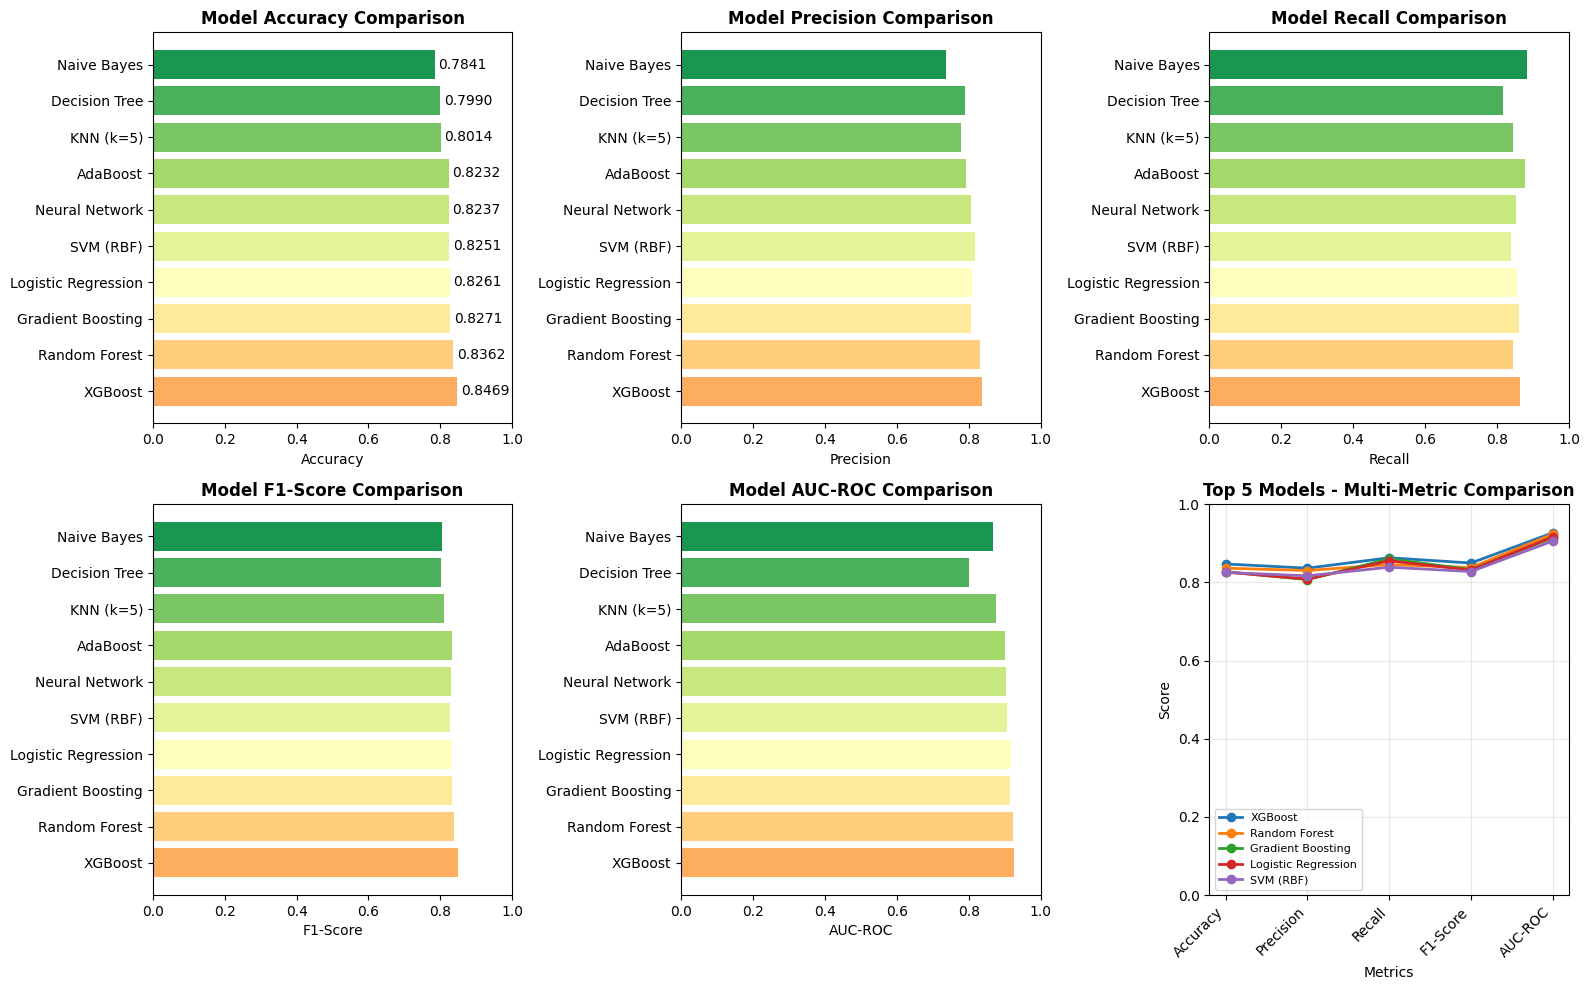

✓ Visualization complete


In [27]:
# ===== 10. VISUALIZE MODEL COMPARISON =====
print("\n" + "="*60)
print("VISUALIZATION: MODEL PERFORMANCE COMPARISON")
print("="*60)

# Create comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))

# 1. Accuracy Comparison
ax = axes[0, 0]
bars = ax.barh(results_df['Model'], results_df['Accuracy'], color=colors_gradient)
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_xlim([0, 1])
for i, v in enumerate(results_df['Accuracy']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center')

# 2. Precision Comparison
ax = axes[0, 1]
bars = ax.barh(results_df['Model'], results_df['Precision'], color=colors_gradient)
ax.set_xlabel('Precision')
ax.set_title('Model Precision Comparison', fontweight='bold')
ax.set_xlim([0, 1])

# 3. Recall Comparison
ax = axes[0, 2]
bars = ax.barh(results_df['Model'], results_df['Recall'], color=colors_gradient)
ax.set_xlabel('Recall')
ax.set_title('Model Recall Comparison', fontweight='bold')
ax.set_xlim([0, 1])

# 4. F1-Score Comparison
ax = axes[1, 0]
bars = ax.barh(results_df['Model'], results_df['F1-Score'], color=colors_gradient)
ax.set_xlabel('F1-Score')
ax.set_title('Model F1-Score Comparison', fontweight='bold')
ax.set_xlim([0, 1])

# 5. AUC-ROC Comparison
ax = axes[1, 1]
bars = ax.barh(results_df['Model'], results_df['AUC-ROC'], color=colors_gradient)
ax.set_xlabel('AUC-ROC')
ax.set_title('Model AUC-ROC Comparison', fontweight='bold')
ax.set_xlim([0, 1])

# 6. Radar-style comparison (top 5 models)
ax = axes[1, 2]
top_5_models = results_df.head(5)
x_pos = np.arange(len(metrics))
width = 0.15

for idx, (i, row) in enumerate(top_5_models.iterrows()):
    values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score'], row['AUC-ROC']]
    ax.plot(x_pos, values, marker='o', label=row['Model'], linewidth=2)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Top 5 Models - Multi-Metric Comparison', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend(loc='best', fontsize=8)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


DETAILED ANALYSIS: TOP 3 MODELS

1. XGBoost
------------------------------------------------------------
Accuracy:  0.8469
Precision: 0.8361
Recall:    0.8628
F1-Score:  0.8493
AUC-ROC:   0.9264

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.84      0.86      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070


2. Random Forest
------------------------------------------------------------
Accuracy:  0.8362
Precision: 0.8302
Recall:    0.8454
F1-Score:  0.8377
AUC-ROC:   0.9230

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.83      1035
       Churn       0.83      0.85      0.84      1035

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.8

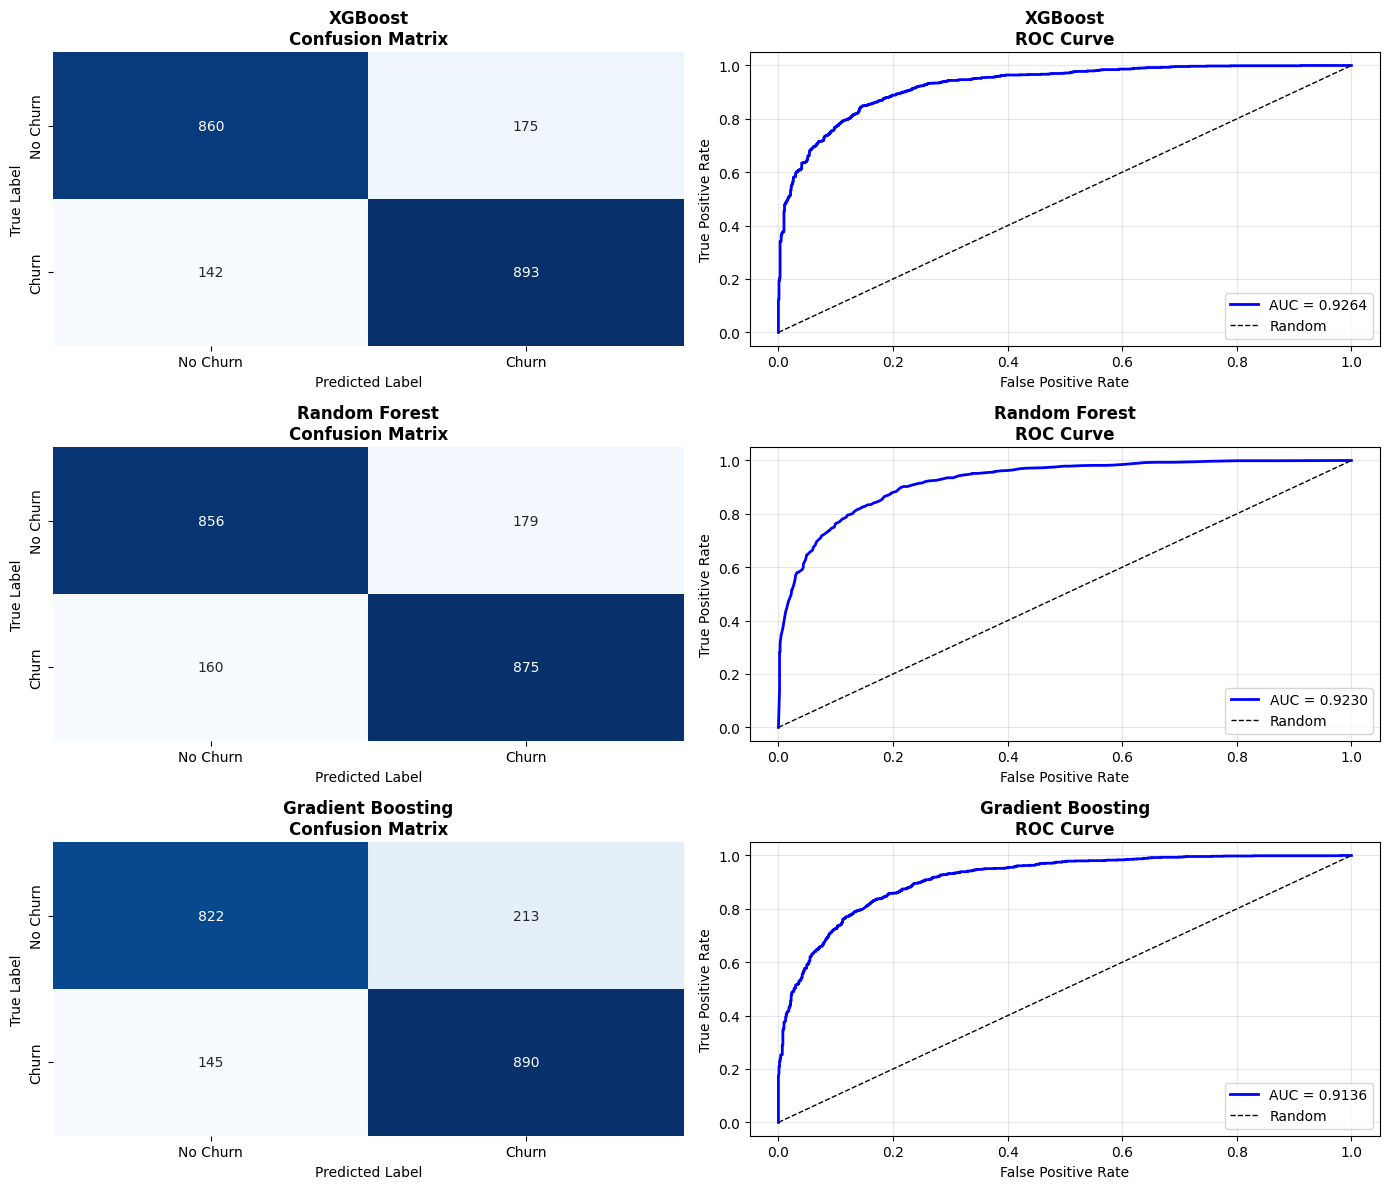


SUMMARY & RECOMMENDATIONS

✓ Best Model: XGBoost
✓ Accuracy: 0.8469

✓ Top 3 Models for Production:
  1. XGBoost                   Accuracy: 0.8469
  2. Random Forest             Accuracy: 0.8362
  3. Gradient Boosting         Accuracy: 0.8271

✓ Model trained on 8278 samples
✓ Tested on 2070 samples
✓ Ready for deployment!


In [28]:
# ===== 11. DETAILED ANALYSIS OF TOP 3 MODELS =====
print("\n" + "="*60)
print("DETAILED ANALYSIS: TOP 3 MODELS")
print("="*60)

from sklearn.metrics import classification_report, confusion_matrix

top_3_models = results_df.head(3)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row_idx, (i, model_info) in enumerate(top_3_models.iterrows()):
    model_name = model_info['Model']
    model = model_objects[model_name]
    
    print(f"\n{row_idx + 1}. {model_name}")
    print("-" * 60)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    print(f"Accuracy:  {model_info['Accuracy']:.4f}")
    print(f"Precision: {model_info['Precision']:.4f}")
    print(f"Recall:    {model_info['Recall']:.4f}")
    print(f"F1-Score:  {model_info['F1-Score']:.4f}")
    print(f"AUC-ROC:   {model_info['AUC-ROC']:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    # Confusion Matrix - Left plot
    cm = confusion_matrix(y_test, y_pred)
    ax_left = axes[row_idx, 0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_left,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax_left.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    ax_left.set_ylabel('True Label')
    ax_left.set_xlabel('Predicted Label')
    
    # ROC Curve - Right plot
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    ax_right = axes[row_idx, 1]
    ax_right.plot(fpr, tpr, label=f'AUC = {model_info["AUC-ROC"]:.4f}', linewidth=2, color='blue')
    ax_right.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax_right.set_xlabel('False Positive Rate')
    ax_right.set_ylabel('True Positive Rate')
    ax_right.set_title(f'{model_name}\nROC Curve', fontweight='bold')
    ax_right.legend(loc='lower right')
    ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY & RECOMMENDATIONS")
print("="*60)
print(f"\n✓ Best Model: {results_df.iloc[0]['Model']}")
print(f"✓ Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"\n✓ Top 3 Models for Production:")
for idx, (i, row) in enumerate(top_3_models.iterrows(), 1):
    print(f"  {idx}. {row['Model']:<25} Accuracy: {row['Accuracy']:.4f}")

print(f"\n✓ Model trained on {len(X_train)} samples")
print(f"✓ Tested on {len(X_test)} samples")
print(f"✓ Ready for deployment!")

In [30]:
# ===== BAYESIAN OPTIMIZATION HYPERPARAMETER TUNING =====
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

print("\n" + "="*60)
print("BAYESIAN OPTIMIZATION HYPERPARAMETER TUNING")
print("="*60)

# Define search spacet
search_space = {
    'n_estimators': Integer(100, 250),
    'max_depth': Integer(10, 30),
    'min_samples_split': Integer(2, 15),
    'min_samples_leaf': Integer(1, 6),
    'max_features': Categorical(['sqrt', 'log2'])
}

# Create BayesSearchCV
bayes_search = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    search_space,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Training BayesSearchCV...")
start = time.time()
bayes_search.fit(X_train_scaled, y_train)
bayes_time = time.time() - start

print(f"\nBest Parameters: {bayes_search.best_params_}")
print(f"Best CV F1-Score: {bayes_search.best_score_:.4f}")
print(f"Time: {bayes_time:.2f}s")

# Evaluate on test set
y_pred_bayes = bayes_search.predict(X_test_scaled)
y_pred_proba_bayes = bayes_search.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Results:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_bayes):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_bayes):.4f}")
print(f"  AUC-ROC: {roc_auc_score(y_test, y_pred_proba_bayes):.4f}")

bayes_model = bayes_search.best_estimator_


BAYESIAN OPTIMIZATION HYPERPARAMETER TUNING
Training BayesSearchCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, to

In [31]:
# ===== COMPARISON: GRIDSEARCH vs BAYESIAN =====
print("\n" + "="*60)
print("COMPARISON: GRIDSEARCH vs BAYESIAN OPTIMIZATION")
print("="*60)

comparison = pd.DataFrame({
    'Method': ['GridSearch', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_bayes)
    ],
    'Test F1-Score': [
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_bayes)
    ],
    'Test AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_grid),
        roc_auc_score(y_test, y_pred_proba_bayes)
    ],
    'Time (seconds)': [grid_time, bayes_time]
})

print("\n" + comparison.to_string(index=False))

# Determine winner
best_method = 'GridSearch' if grid_search.best_score_ > bayes_search.best_score_ else 'Bayesian Optimization'
print(f"\n✓ Winner (Higher CV Score): {best_method}")
print(f"  GridSearch Best Params: {grid_search.best_params_}")
print(f"  Bayesian Best Params: {bayes_search.best_params_}")


COMPARISON: GRIDSEARCH vs BAYESIAN OPTIMIZATION

               Method  Best CV Score  Test Accuracy  Test F1-Score  Test AUC-ROC  Time (seconds)
           GridSearch       0.845746       0.836232        0.84032      0.920162      288.790179
Bayesian Optimization       0.845802       0.836232        0.84032      0.923995      117.576054

✓ Winner (Higher CV Score): Bayesian Optimization
  GridSearch Best Params: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
  Bayesian Best Params: OrderedDict([('max_depth', 17), ('max_features', 'sqrt'), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 158)])


In [36]:
# ===== SAVE BEST TUNED MODELS (PICKLE) =====
import joblib

# Resolve best estimators safely
best_grid_model = grid_model if 'grid_model' in globals() else grid_search.best_estimator_
best_bayes_model = bayes_model if 'bayes_model' in globals() else bayes_search.best_estimator_

# Save model artifacts
joblib.dump(best_grid_model, 'best_model_gridsearch_rf.pkl')
joblib.dump(best_bayes_model, 'best_model_bayesian_rf.pkl')

# Save useful metadata
joblib.dump(grid_search.best_params_, 'best_params_gridsearch.pkl')
joblib.dump(dict(bayes_search.best_params_), 'best_params_bayesian.pkl')

print('Saved files:')
print('1) best_model_gridsearch_rf.pkl')
print('2) best_model_bayesian_rf.pkl')
print('3) best_params_gridsearch.pkl')
print('4) best_params_bayesian.pkl')

Saved files:
1) best_model_gridsearch_rf.pkl
2) best_model_bayesian_rf.pkl
3) best_params_gridsearch.pkl
4) best_params_bayesian.pkl


/home/xeeshan/anaconda3/envs/myenv/lib/python3.9/site-packages/debugpy/_vendored/force_pydevd.py:18: UserWarning: incompatible copy of pydevd already imported:
 /home/xeeshan/anaconda3/envs/myenv/lib/python3.9/site-packages/pydevd_plugins/extensions/pydevd_plugin_omegaconf.py
  warnings.warn(msg + ':\n {}'.format('\n  '.join(_unvendored)))


SHAP ANALYSIS: FEATURE CONTRIBUTIONS

1. GridSearch Model - SHAP Analysis
------------------------------------------------------------


<Figure size 1000x600 with 0 Axes>

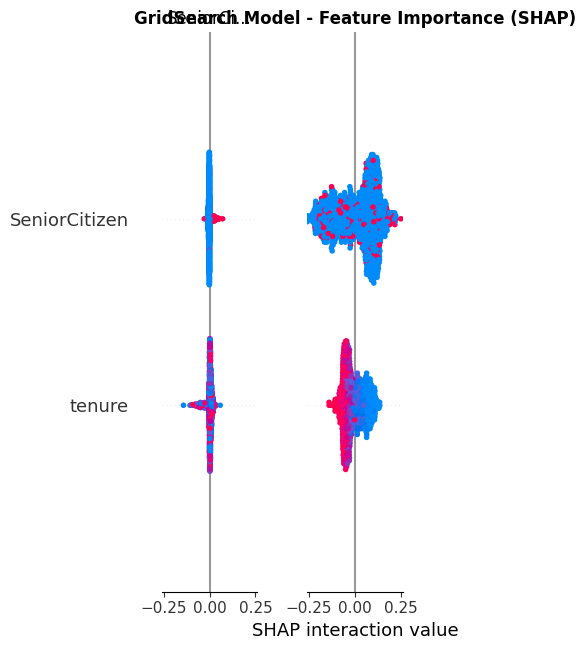

<Figure size 1000x800 with 0 Axes>

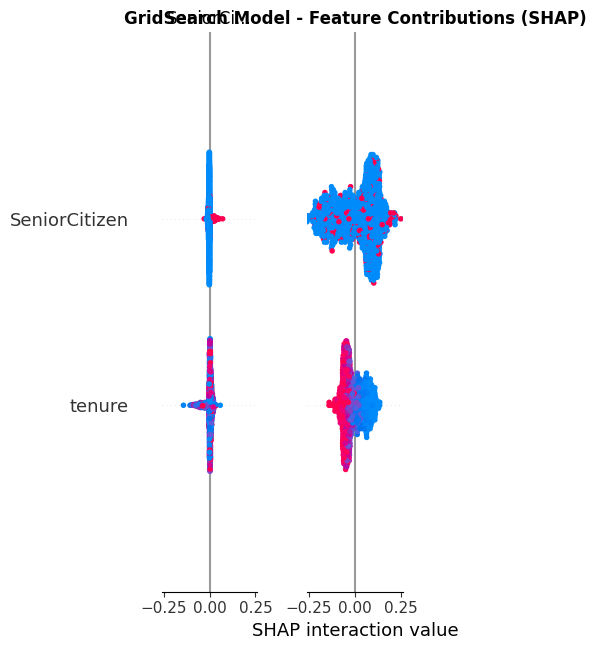

✓ GridSearch SHAP analysis complete

2. Bayesian Model - SHAP Analysis
------------------------------------------------------------


<Figure size 1000x600 with 0 Axes>

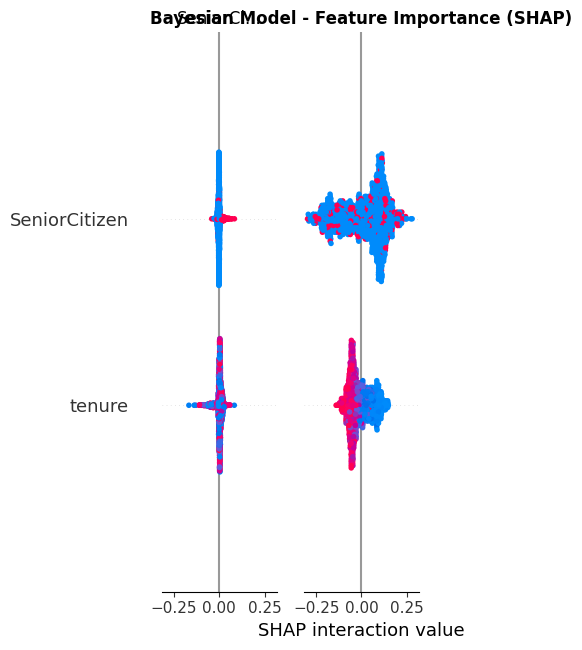

<Figure size 1000x800 with 0 Axes>

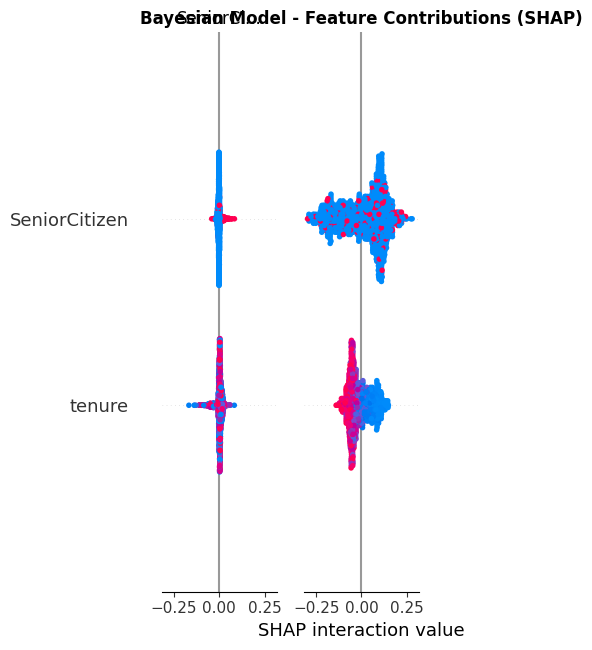

✓ Bayesian SHAP analysis complete

TOP 5 MOST IMPORTANT FEATURES (by SHAP)


ValueError: Per-column arrays must each be 1-dimensional

In [37]:
# ===== SHAP ANALYSIS: FEATURE CONTRIBUTIONS =====
import subprocess
import sys

# Install SHAP
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])

import shap
import matplotlib.pyplot as plt

print("="*60)
print("SHAP ANALYSIS: FEATURE CONTRIBUTIONS")
print("="*60)

# Use test data for SHAP analysis
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# ===== SHAP for GridSearch Model =====
print("\n1. GridSearch Model - SHAP Analysis")
print("-"*60)

# Create explainer
explainer_grid = shap.TreeExplainer(best_grid_model)
shap_values_grid = explainer_grid.shap_values(X_test_df)

# Summary plot - Bar (mean |SHAP| per feature)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_grid, X_test_df, plot_type="bar", show=False)
plt.title("GridSearch Model - Feature Importance (SHAP)", fontweight='bold')
plt.tight_layout()
plt.show()

# Summary plot - Beeswarm (detailed feature contribution)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_grid, X_test_df, show=False)
plt.title("GridSearch Model - Feature Contributions (SHAP)", fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ GridSearch SHAP analysis complete")

# ===== SHAP for Bayesian Model =====
print("\n2. Bayesian Model - SHAP Analysis")
print("-"*60)

# Create explainer
explainer_bayes = shap.TreeExplainer(best_bayes_model)
shap_values_bayes = explainer_bayes.shap_values(X_test_df)

# Summary plot - Bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_bayes, X_test_df, plot_type="bar", show=False)
plt.title("Bayesian Model - Feature Importance (SHAP)", fontweight='bold')
plt.tight_layout()
plt.show()

# Summary plot - Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_bayes, X_test_df, show=False)
plt.title("Bayesian Model - Feature Contributions (SHAP)", fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Bayesian SHAP analysis complete")

# ===== Top Feature Contributions =====
print("\n" + "="*60)
print("TOP 5 MOST IMPORTANT FEATURES (by SHAP)")
print("="*60)

# Calculate mean absolute SHAP values
mean_shap_grid = np.abs(shap_values_grid).mean(axis=0)
mean_shap_bayes = np.abs(shap_values_bayes).mean(axis=0)

# Create comparison
top_features = pd.DataFrame({
    'Feature': X.columns,
    'GridSearch (Mean |SHAP|)': mean_shap_grid,
    'Bayesian (Mean |SHAP|)': mean_shap_bayes
})
top_features['Average'] = (top_features['GridSearch (Mean |SHAP|)'] + top_features['Bayesian (Mean |SHAP|)']) / 2
top_features = top_features.sort_values('Average', ascending=False)

print("\n", top_features.head(10).to_string(index=False))

print("\n✓ SHAP analysis complete!")

In [40]:
# ===== MLFLOW TRACKING (NOTEBOOK) =====
import subprocess
import sys

# Install mlflow only if missing
try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mlflow', '-q'])
    import mlflow
    import mlflow.sklearn

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('=' * 60)
print('MLFLOW TRACKING FOR GRIDSEARCH & BAYESIAN MODELS')
print('=' * 60)

# Resolve models safely from existing notebook variables
best_grid_model = grid_model if 'grid_model' in globals() else grid_search.best_estimator_
best_bayes_model = bayes_model if 'bayes_model' in globals() else bayes_search.best_estimator_

# Always recompute predictions from current X_test_scaled/y_test to avoid stale arrays
y_pred_grid = best_grid_model.predict(X_test_scaled)
y_pred_proba_grid = best_grid_model.predict_proba(X_test_scaled)[:, 1]
y_pred_bayes = best_bayes_model.predict(X_test_scaled)
y_pred_proba_bayes = best_bayes_model.predict_proba(X_test_scaled)[:, 1]

# Build metric dictionaries
grid_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_grid),
    'precision': precision_score(y_test, y_pred_grid, zero_division=0),
    'recall': recall_score(y_test, y_pred_grid, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_grid, zero_division=0),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_grid),
    'cv_best_score': float(grid_search.best_score_) if 'grid_search' in globals() else float('nan'),
    'train_time_sec': float(grid_time) if 'grid_time' in globals() else float('nan')
}

bayes_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_bayes),
    'precision': precision_score(y_test, y_pred_bayes, zero_division=0),
    'recall': recall_score(y_test, y_pred_bayes, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_bayes, zero_division=0),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_bayes),
    'cv_best_score': float(bayes_search.best_score_) if 'bayes_search' in globals() else float('nan'),
    'train_time_sec': float(bayes_time) if 'bayes_time' in globals() else float('nan')
}

# MLflow setup
mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('churn_prediction_random_forest_notebook')

X_example = X_test_scaled[:5]

def _clean_params(params_dict):
    clean = {}
    for k, v in params_dict.items():
        if hasattr(v, 'item'):
            clean[k] = v.item()
        else:
            clean[k] = v
    return clean

# Log GridSearch run
with mlflow.start_run(run_name='gridsearch_random_forest_notebook') as run:
    if 'grid_search' in globals():
        mlflow.log_params(_clean_params(grid_search.best_params_))
    mlflow.log_metrics(grid_metrics)
    mlflow.set_tag('model_family', 'RandomForest')
    mlflow.set_tag('tuning_method', 'GridSearchCV')
    mlflow.sklearn.log_model(best_grid_model, artifact_path='model', input_example=X_example)
    grid_run_id = run.info.run_id

# Log Bayesian run
with mlflow.start_run(run_name='bayesian_random_forest_notebook') as run:
    if 'bayes_search' in globals():
        mlflow.log_params(_clean_params(dict(bayes_search.best_params_)))
    mlflow.log_metrics(bayes_metrics)
    mlflow.set_tag('model_family', 'RandomForest')
    mlflow.set_tag('tuning_method', 'BayesSearchCV')
    mlflow.sklearn.log_model(best_bayes_model, artifact_path='model', input_example=X_example)
    bayes_run_id = run.info.run_id

print('\n✓ MLflow logging complete')
print(f'GridSearch run_id: {grid_run_id}')
print(f'Bayesian run_id:   {bayes_run_id}')
print('\nTo open UI, run in terminal:')
print('mlflow ui --backend-store-uri file:./mlruns --port 5000')
print('Then open: http://127.0.0.1:5000')

MLFLOW TRACKING FOR GRIDSEARCH & BAYESIAN MODELS


2026/03/23 19:14:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 19:14:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✓ MLflow logging complete
GridSearch run_id: 54d18ce470364f9a8ae2d814461cfdf8
Bayesian run_id:   7a8e9def9bd246059c1d3520113abf65

To open UI, run in terminal:
mlflow ui --backend-store-uri file:./mlruns --port 5000
Then open: http://127.0.0.1:5000
